In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import black_scholes as bs
import Monte_Carlo as mc
import barriere as br

### Paramètres généraux

In [2]:
S= 100.
K= 100.
r= 0.03
q = 0.01
sigma = 0.20
T = 1.0
graine = 0
n_sims = 100000
n_pas = 500
kind = "put"
B=80

### Simulation d'Options barrières

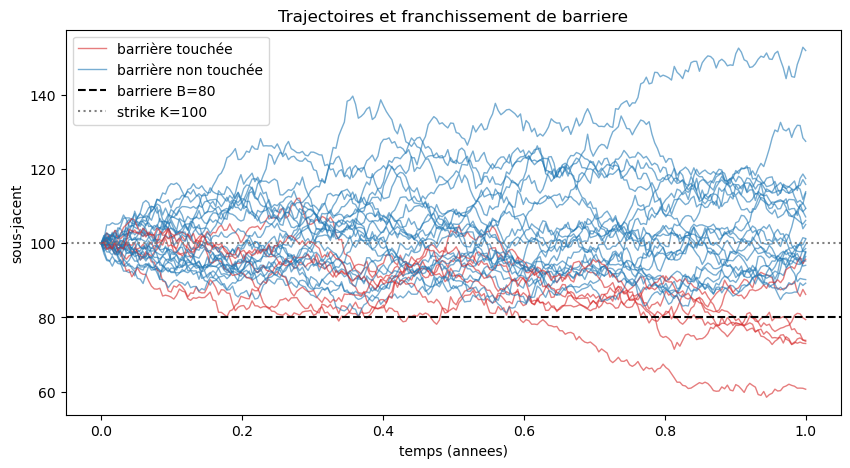

7 trajectoires sur 30 franchissent la barriere


In [3]:
n_traj = 30
chemins = br.simuler_chemins(S, r, q, sigma, T, n_pas=252, n_sims=n_traj, seed=1)
dates = np.linspace(0, T, chemins.shape[1])

minimums = chemins.min(axis=1)
touchees = minimums<=B 

plt.figure(figsize=(10, 5))

#On conditionne les labels pour pas en afficher 30
label_touchees_fait = False
label_survivante_fait = False
for i in range(n_traj):
    if touchees[i] and not label_touchees_fait:
        label = 'barrière touchée'
        label_touchees_fait = True
    elif not touchees[i] and not label_survivante_fait:
        label = 'barrière non touchée'
        label_survivante_fait = True
    else:
        label = None
    plt.plot(dates, chemins[i],"tab:red" if touchees[i] else "tab:blue", label=label, alpha=0.6, linewidth=1)

plt.axhline(B, color="black", linestyle="--", label=f"barriere B={B:.0f}")
plt.axhline(K, color="grey", linestyle=":", label=f"strike K={K:.0f}")
plt.xlabel("temps (annees)")
plt.ylabel("sous-jacent")
plt.title("Trajectoires et franchissement de barriere")
plt.legend()
plt.show()

print(f"{touchees.sum()} trajectoires sur {n_traj} franchissent la barriere")



### Parité graphique in + out = vanille

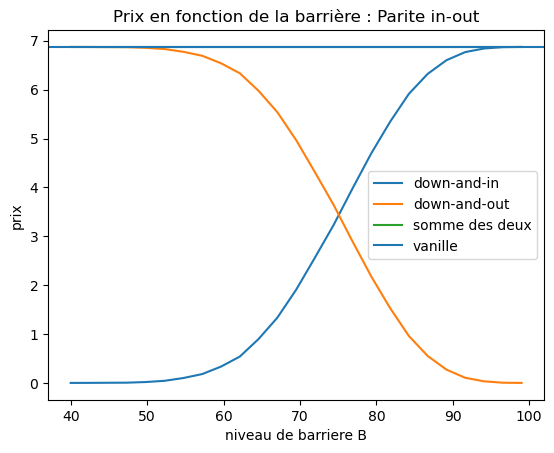

In [4]:

niveaux = np.linspace(40., 99., 25)
prix_di, prix_do = [], []
vanille = bs.price(S, K, r, q, sigma, T, kind="put")

for b in niveaux:
    di,_ = br.prix_barriere_mc(S, K, r, q, sigma, T, b, type_barriere="down-and-in",
                     kind="put", n_pas=252, n_sims=50_000, seed=graine)
    do,_ = br.prix_barriere_mc(S, K, r, q, sigma, T, b, type_barriere="down-and-out",
                     kind="put", n_pas=252, n_sims=50_000, seed=graine)
    prix_di.append(di)
    prix_do.append(do)

prix_di = np.asarray(prix_di)
prix_do = np.asarray(prix_do)


plt.plot(niveaux, prix_di, label="down-and-in")
plt.plot(niveaux, prix_do, label="down-and-out")
plt.plot(niveaux,prix_di+prix_do,label='somme des deux')
plt.axhline(vanille,label='vanille')
plt.xlabel("niveau de barriere B")
plt.ylabel("prix")
plt.title("Prix en fonction de la barrière : Parite in-out")
plt.legend()
plt.show()

La parité in-out est bien respectée

### Etude du biais d'observation discrèt de la barrière (nombre de pas)

l'option barrière est observé un certain nombre de fois durant sa vie, ce qui sous-estime sa capacité à franchir la barrière par rapport à une observation continue

Analyse : On observe que le biais de monitoring est bien en dessous de 0 a toute date d'observation : en effet on travaille avec une barrière knock-in ici, donc avoir des observations discrètes (moins nombreuses que en continu par défintion) sous-estime donc par construction la probabilité d'entrer dans l'option. Inversement plus on augmente le nombre de pas, plus ce biais est petit et se rapproche de 0

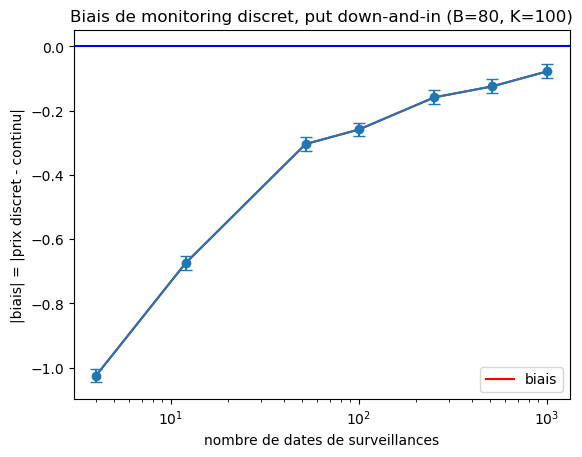

In [5]:
etude = br.etude_biais_monitoring(S, K, r, q, sigma, T, B,
                           type_barriere="down-and-in", kind="put",
                           liste_pas=(4, 12, 52, 100, 252, 512, 1000), n_sims=200_000, seed=graine)
plt.plot(etude["n_pas"],etude["biais"],label='biais',color='red')
plt.errorbar(etude["n_pas"], etude["biais"], yerr=etude["err_std"],marker="o", capsize=4)
plt.axhline(0,color='blue')
plt.xscale("log")
plt.title(f"Biais de monitoring discret, put down-and-in (B={B:.0f}, K={K:.0f})")
plt.xlabel('nombre de dates de surveillances')
plt.ylabel('|biais| = |prix discret - continu|')
plt.legend()
plt.show()


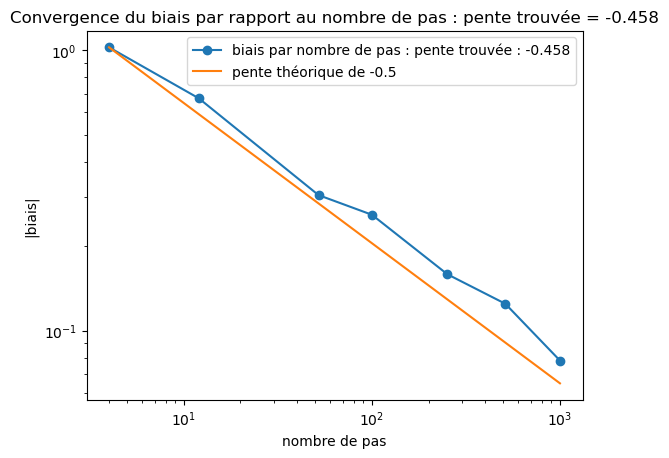

In [6]:
biais_abs = np.abs(etude["biais"])
pente, ordonnee = np.polyfit(np.log(etude["n_pas"]),np.log(biais_abs),1)
plt.loglog(etude["n_pas"],biais_abs,label=f'biais par nombre de pas : pente trouvée : {pente:.3f}',marker='o')

ref = biais_abs[0] * (etude["n_pas"] / etude["n_pas"][0])**(-0.5)
plt.loglog(etude["n_pas"],ref,label='pente théorique de -0.5')

plt.xlabel('nombre de pas')
plt.ylabel('|biais|')
plt.title(f'Convergence du biais par rapport au nombre de pas : pente trouvée = {pente:.3f}')
plt.legend()
plt.show()


La pente trouvée est très proche de celle théorique de -0.5. (Le biais converge en racine de n). Donc il faux 100 fois plus de pas pour diviser le biais par 10

### Etude de la correction  Broadie sur le biais de la barrière

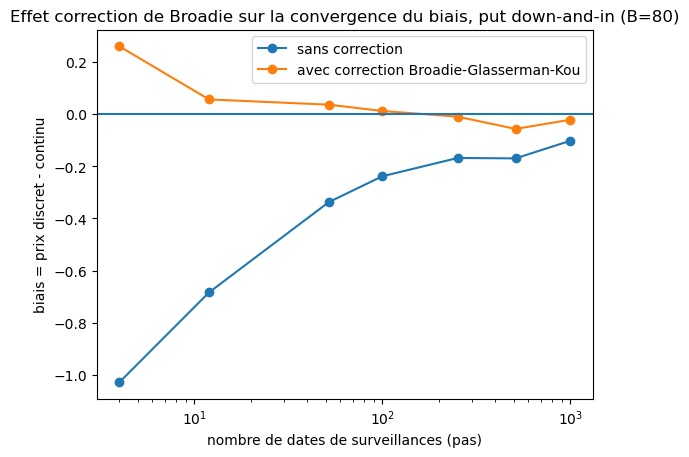

In [7]:
liste_pas=[4, 12, 52, 100, 252, 512, 1000]
graine = 0
B=80

continu = br.prix_barriere_ferme(S, K, r, q, sigma, T, B, type_barriere="down-and-in", kind="put")

biais_brut = []
biais_corrige = []

for n in liste_pas:
    #biais brut
    prix_b, err_b = br.prix_barriere_mc(S, K, r, q, sigma, T, B, type_barriere="down-and-in",
                     kind="put", n_pas=n, n_sims=50_000, seed=graine)
    biais_b = prix_b - continu
    biais_brut.append(biais_b)

    #biais corrige
    barriere = br.correction_broadie(B, sigma, T, n, sens="down")
    prix_c, err_c = br.prix_barriere_mc(S, K, r, q, sigma, T, barriere, type_barriere="down-and-in",
                         kind="put", n_pas=n, n_sims=50_000, seed=graine)
    biais_c = prix_c - continu
    biais_corrige.append(biais_c)

biais_brut = np.asarray(biais_brut)
biais_corrige = np.asarray(biais_corrige)

plt.plot(liste_pas,biais_brut,marker='o',label='sans correction')
plt.plot(liste_pas,biais_corrige,marker='o',label='avec correction Broadie-Glasserman-Kou')

plt.axhline(0)
plt.xscale("log")
plt.xlabel('nombre de dates de surveillances (pas)')
plt.ylabel('biais = prix discret - continu')
plt.title(f'Effet correction de Broadie sur la convergence du biais, put down-and-in (B={B:.0f})')
plt.legend()
plt.show()

On observe que la correction de BGK fonctionne assez bien : on arrive à réduire le biais très fortement même avec un petit pas (à 50 pas, on se rapproche presque autant de 0 voire plus avec la correction que à 1000 pas sans la correction), ce qui permet de décharger le modèle pour qu'il aille plus vite

### Remarque contrainte mémoire

Le calcul des nombre de simulation x dates d'observation prend beaucoup de place : 100 000 observations x 5000 pas x 8 octects = 4gb de mémoire
La correction de broadie est donc indispensable pour limiter ça